# 🤖 Atlanta Housing Pulse — Model Evaluation
**Audience:** Data scientists, ML engineers, technical reviewers  
**Purpose:** End-to-end validation of the GBM Risk Classifier and PSI-based drift monitoring system  
**Pipeline source:** `src/model.py` · `src/monitor.py`  

---
### What We Evaluate
1. **GBM Risk Classifier** — Gradient Boosting Machine trained to predict DRI risk tiers (Low/Moderate/High/Critical)
2. **Cross-validation accuracy** — 5-fold stratified CV
3. **Classification metrics** — Precision, Recall, F1 per class
4. **Confusion matrix** — Tier-level misclassification patterns
5. **Feature importances** — GBM's independent weight vs. manual DRI weights
6. **PSI Drift Monitoring** — Year-over-year feature distribution stability

> **Design note:** The GBM does not *replace* the DRI — it *validates* it. If the model can accurately predict DRI tiers from raw features, it confirms the index correctly captures the latent displacement signal. High feature importances diverging from DRI weights would signal a need to recalibrate the index.


## 1. Setup & Data Load

In [1]:
import os, sqlite3, warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from dotenv import load_dotenv

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, learning_curve
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, accuracy_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              roc_curve, auc)
from sklearn.preprocessing import label_binarize

load_dotenv()
CENSUS_API_KEY = os.getenv("CENSUS_API_KEY")
FRED_API_KEY   = os.getenv("FRED_API_KEY")
print(f"CENSUS_API_KEY: {'✅' if CENSUS_API_KEY else '❌ MISSING'}")
print(f"FRED_API_KEY:   {'✅' if FRED_API_KEY   else '❌ MISSING'}")

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False,
                     "axes.spines.right": False, "font.family": "DejaVu Sans"})
DB_PATH = "housing_pulse.db"
TIER_ORDER = ["Low", "Moderate", "High", "Critical"]
PALETTE    = {"Critical":"#c0392b","High":"#e67e22","Moderate":"#f1c40f","Low":"#27ae60"}


CENSUS_API_KEY: ✅
FRED_API_KEY:   ✅


In [2]:
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql("SELECT * FROM tracts_with_features", conn)
try:
    drift_df = pd.read_sql("SELECT * FROM drift_log", conn)
    has_drift = True
except:
    has_drift = False
    drift_df = pd.DataFrame()
conn.close()

print(f"✅ Feature table: {df.shape}")
print(f"✅ Drift log available: {has_drift}")
print(f"   Risk tier distribution:\n{df['risk_tier'].value_counts().to_string()}")


✅ Feature table: (3018, 27)
✅ Drift log available: True
   Risk tier distribution:
risk_tier
High        1544
Moderate     793
Critical     332
Low           27


## 2. Feature Set & Class Balance

In [3]:
FEATURES = [
    "rent_burden_pct", "rent_to_income_ratio", "vacancy_rate",
    "median_income", "median_rent", "low_vacancy_score",
    "low_income_score", "gentrif_pressure_flag",
]
FEATURES = [f for f in FEATURES if f in df.columns]
print(f"Features used: {FEATURES}")

df_model = df.dropna(subset=FEATURES + ["risk_tier"]).copy()
le = LabelEncoder()
le.fit(TIER_ORDER)
df_model["y"] = le.transform(df_model["risk_tier"])
X = df_model[FEATURES]
y = df_model["y"]

print(f"\nModel dataset: {len(df_model):,} rows")
print(f"Class distribution:")
for t in TIER_ORDER:
    n = (df_model["risk_tier"] == t).sum()
    print(f"  {t:10s}: {n:4d}  ({n/len(df_model)*100:.1f}%)")


Features used: ['rent_burden_pct', 'rent_to_income_ratio', 'vacancy_rate', 'median_income', 'median_rent', 'low_vacancy_score', 'low_income_score', 'gentrif_pressure_flag']

Model dataset: 2,696 rows
Class distribution:
  Low       :   27  (1.0%)
  Moderate  :  793  (29.4%)
  High      : 1544  (57.3%)
  Critical  :  332  (12.3%)


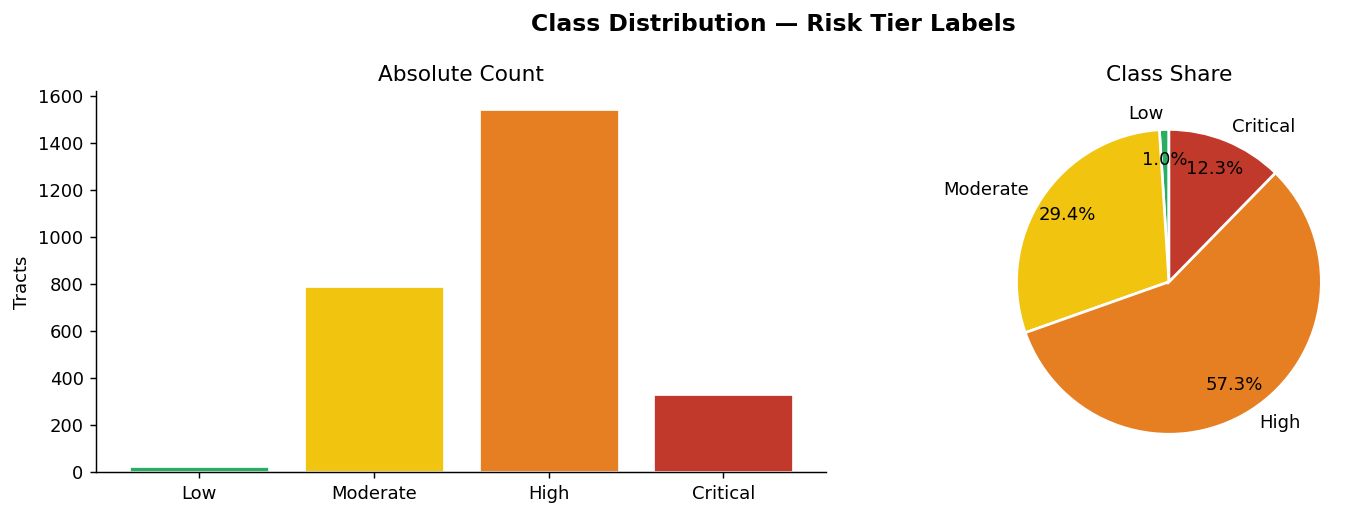

In [4]:
# Class balance visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Class Distribution — Risk Tier Labels", fontsize=13, fontweight="bold")

counts = df_model["risk_tier"].value_counts().reindex(TIER_ORDER, fill_value=0)
axes[0].bar(counts.index, counts.values,
            color=[PALETTE[t] for t in counts.index], edgecolor="white", linewidth=1.5)
axes[0].set_title("Absolute Count")
axes[0].set_ylabel("Tracts")

axes[1].pie(counts.values, labels=counts.index,
            colors=[PALETTE[t] for t in counts.index],
            autopct="%1.1f%%", startangle=90, pctdistance=0.8,
            wedgeprops=dict(edgecolor="white", linewidth=1.5))
axes[1].set_title("Class Share")

plt.tight_layout()
plt.savefig("notebooks/model_class_balance.png", bbox_inches="tight")
plt.show()


## 3. Model Training
**Hyperparameters (as coded in `model.py`):**
```python
GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=4,
    subsample=0.8, min_samples_leaf=5, random_state=42
)
```
Subsample=0.8 introduces stochastic gradient boosting (prevents overfitting).  
Low learning rate + many estimators = slow learner with good generalization.


In [5]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_tr):,} | Test: {len(X_te):,}")

clf = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=4,
    subsample=0.8, min_samples_leaf=5, random_state=42
)
clf.fit(X_tr, y_tr)

y_pred = clf.predict(X_te)
test_acc = accuracy_score(y_te, y_pred)
print(f"\n✅ Test Accuracy: {test_acc:.4f}")


Train: 2,156 | Test: 540



✅ Test Accuracy: 0.9704


## 4. Cross-Validation — 5-Fold Stratified

── 5-Fold Stratified CV Results ─────────────────────────────────────────
  Fold 1: 0.9667  █████████████████████████████
  Fold 2: 0.9647  ████████████████████████████
  Fold 3: 0.9518  ████████████████████████████
  Fold 4: 0.9369  ████████████████████████████
  Fold 5: 0.9536  ████████████████████████████

  Mean:  0.9547
  Std:   0.0107
  Min:   0.9369
  Max:   0.9667


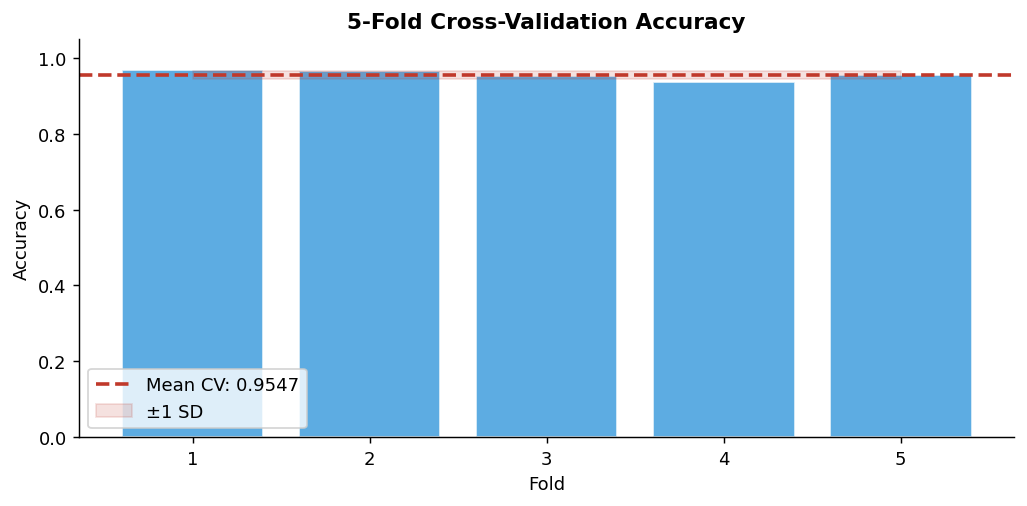

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(clf, X, y, cv=cv, scoring="accuracy")

print("── 5-Fold Stratified CV Results ─────────────────────────────────────────")
for i, s in enumerate(cv_scores, 1):
    bar = "█" * int(s * 30)
    print(f"  Fold {i}: {s:.4f}  {bar}")
print(f"\n  Mean:  {cv_scores.mean():.4f}")
print(f"  Std:   {cv_scores.std():.4f}")
print(f"  Min:   {cv_scores.min():.4f}")
print(f"  Max:   {cv_scores.max():.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, 6), cv_scores, color="#3498db", alpha=0.8, edgecolor="white")
ax.axhline(cv_scores.mean(), color="#c0392b", linestyle="--", linewidth=2,
           label=f"Mean CV: {cv_scores.mean():.4f}")
ax.fill_between(range(1, 6),
                cv_scores.mean() - cv_scores.std(),
                cv_scores.mean() + cv_scores.std(),
                alpha=0.15, color="#c0392b", label="±1 SD")
ax.set_xlabel("Fold"); ax.set_ylabel("Accuracy"); ax.set_ylim(0, 1.05)
ax.set_title("5-Fold Cross-Validation Accuracy", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("notebooks/model_cv.png", bbox_inches="tight")
plt.show()


## 5. Classification Report — Per-Tier Metrics

── Classification Report ─────────────────────────────────────────────────
              precision    recall  f1-score   support

    Critical       0.98      0.97      0.98        67
        High       0.96      0.99      0.98       309
         Low       0.83      1.00      0.91         5
    Moderate       0.99      0.93      0.96       159

    accuracy                           0.97       540
   macro avg       0.94      0.97      0.96       540
weighted avg       0.97      0.97      0.97       540



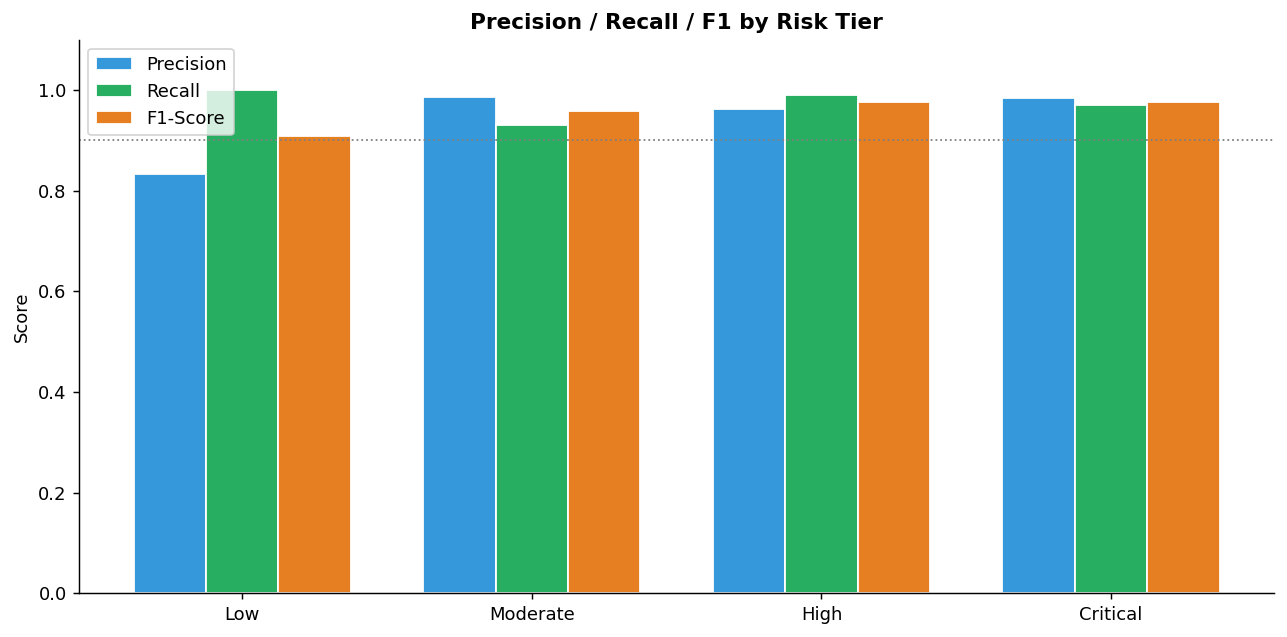

In [7]:
print("── Classification Report ─────────────────────────────────────────────────")
report = classification_report(y_te, y_pred, target_names=le.classes_,
                                output_dict=True)
print(classification_report(y_te, y_pred, target_names=le.classes_))

# Visual report
report_df = pd.DataFrame(report).T.drop(["accuracy","macro avg","weighted avg"], errors="ignore")
report_df = report_df.reindex([t for t in TIER_ORDER if t in report_df.index])
report_df = report_df[["precision","recall","f1-score","support"]].astype(float)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(report_df))
w = 0.25
ax.bar(x - w, report_df["precision"], w, label="Precision",
       color="#3498db", edgecolor="white")
ax.bar(x,     report_df["recall"],    w, label="Recall",
       color="#27ae60", edgecolor="white")
ax.bar(x + w, report_df["f1-score"],  w, label="F1-Score",
       color="#e67e22", edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(report_df.index)
ax.set_ylabel("Score"); ax.set_ylim(0, 1.1)
ax.set_title("Precision / Recall / F1 by Risk Tier", fontweight="bold")
ax.legend(); ax.axhline(0.9, color="gray", linestyle=":", linewidth=1)
plt.tight_layout()
plt.savefig("notebooks/model_report.png", bbox_inches="tight")
plt.show()


## 6. Confusion Matrix

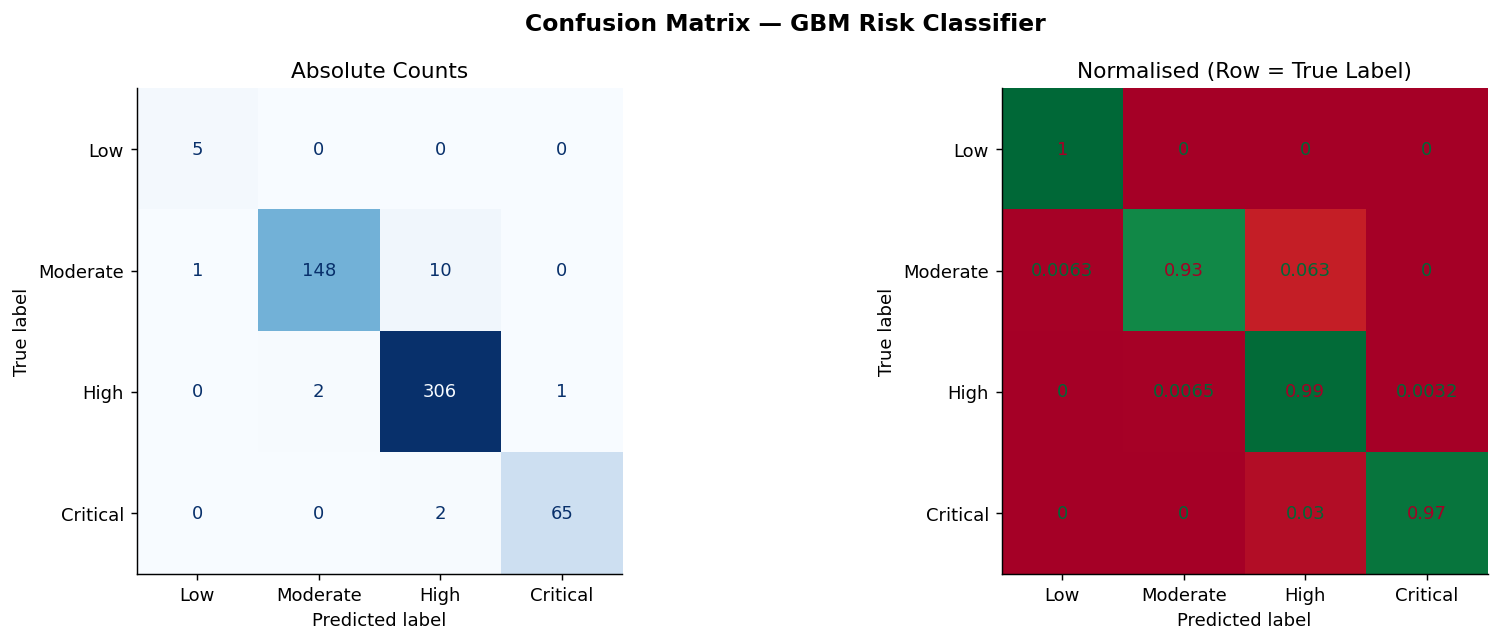


── Critical Misclassification Check ─────────────────────────────────────
  ⚠️ ADJACENT: Moderate predicted as Low — 1 cases
  ⚠️ ADJACENT: Moderate predicted as High — 10 cases
  ⚠️ ADJACENT: High predicted as Moderate — 2 cases
  ⚠️ ADJACENT: High predicted as Critical — 1 cases
  ⚠️ ADJACENT: Critical predicted as High — 2 cases


In [8]:
cm = confusion_matrix(y_te, y_pred, labels=le.transform(
    [t for t in TIER_ORDER if t in le.classes_]
))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Confusion Matrix — GBM Risk Classifier", fontsize=13, fontweight="bold")

tier_labels = [t for t in TIER_ORDER if t in le.classes_]

# Absolute counts
disp = ConfusionMatrixDisplay(cm, display_labels=tier_labels)
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Absolute Counts")

# Normalised (recall)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp2 = ConfusionMatrixDisplay(cm_norm, display_labels=tier_labels)
disp2.plot(ax=axes[1], colorbar=False, cmap="RdYlGn")
axes[1].set_title("Normalised (Row = True Label)")

plt.tight_layout()
plt.savefig("notebooks/model_confusion.png", bbox_inches="tight")
plt.show()

# Highlight misclassifications between adjacent tiers
print("\n── Critical Misclassification Check ─────────────────────────────────────")
tier_map = {i: t for i, t in enumerate(tier_labels)}
for i in range(len(tier_labels)):
    for j in range(len(tier_labels)):
        if i != j and cm[i][j] > 0:
            severity = "⚠️ ADJACENT" if abs(i-j)==1 else "❌ NON-ADJACENT"
            print(f"  {severity}: {tier_map[i]} predicted as {tier_map[j]} — {cm[i][j]} cases")


## 7. Feature Importances — GBM vs. DRI Manual Weights

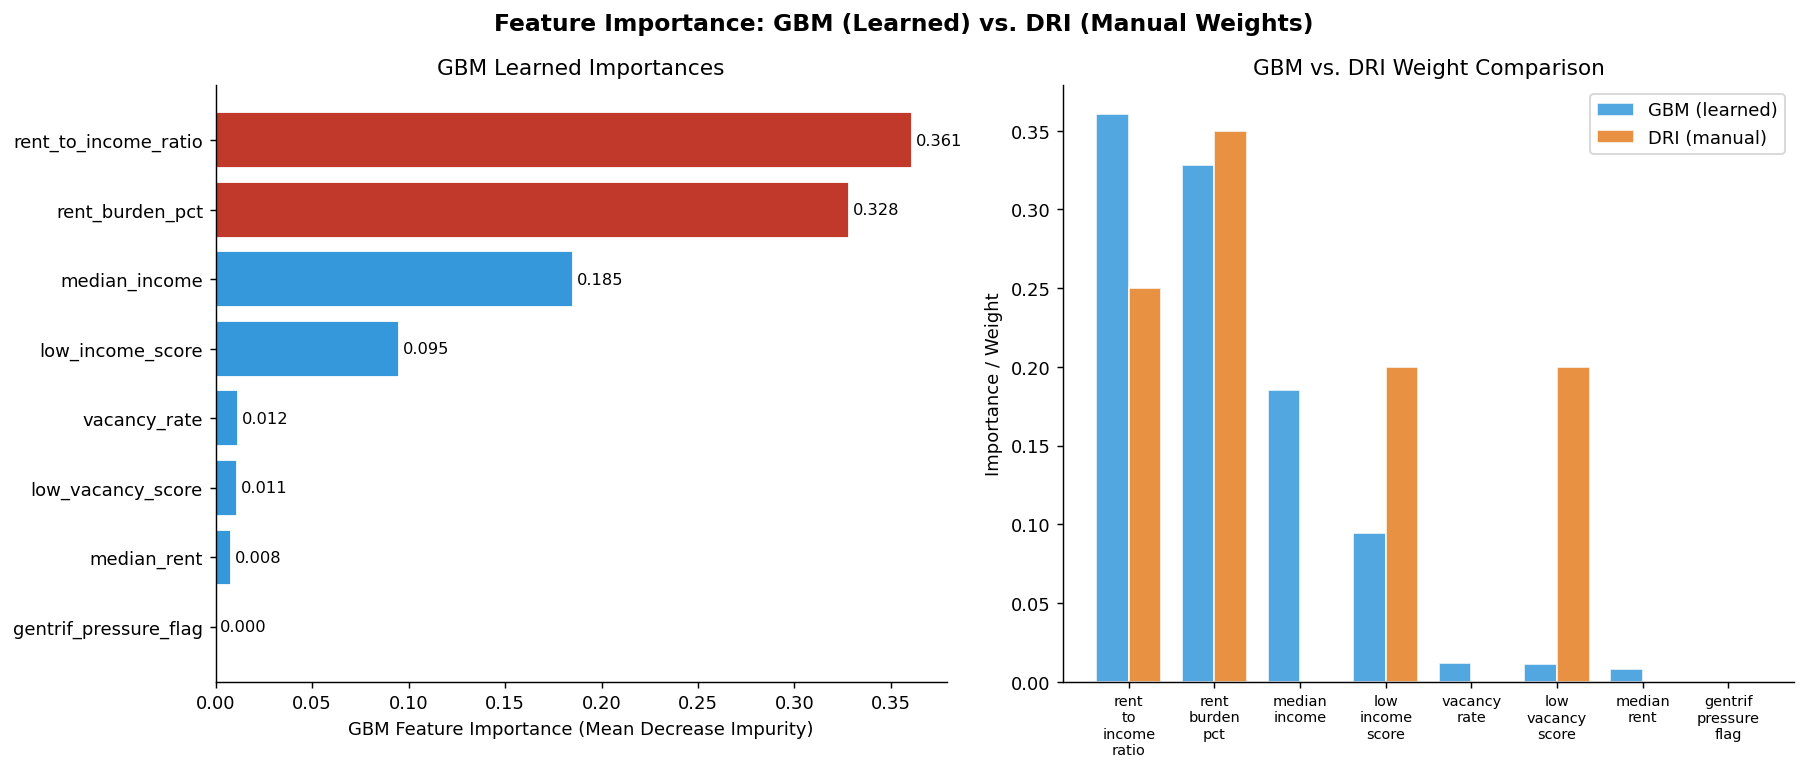


── Divergence: |GBM importance − DRI weight| ───────────────────────────
  rent_to_income_ratio          : GBM=0.361  DRI=0.250  Δ=0.111 ← review
  rent_burden_pct               : GBM=0.328  DRI=0.350  Δ=0.022
  median_income                 : GBM=0.185  DRI=0.000  Δ=0.185 ← review
  low_income_score              : GBM=0.095  DRI=0.200  Δ=0.105 ← review
  vacancy_rate                  : GBM=0.012  DRI=0.000  Δ=0.012
  low_vacancy_score             : GBM=0.011  DRI=0.200  Δ=0.189 ← review
  median_rent                   : GBM=0.008  DRI=0.000  Δ=0.008
  gentrif_pressure_flag         : GBM=0.000  DRI=0.000  Δ=0.000


In [9]:
importances = pd.Series(clf.feature_importances_, index=FEATURES).sort_values(ascending=True)

DRI_WEIGHTS = {
    "rent_burden_pct":     0.35,
    "rent_to_income_ratio":0.25,
    "low_vacancy_score":   0.20,
    "low_income_score":    0.20,
    "vacancy_rate":        0.0,
    "median_income":       0.0,
    "median_rent":         0.0,
    "gentrif_pressure_flag": 0.0,
}
dri_wt = pd.Series({k: DRI_WEIGHTS.get(k, 0) for k in FEATURES})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Feature Importance: GBM (Learned) vs. DRI (Manual Weights)", fontsize=13, fontweight="bold")

# GBM importances
colors = ["#c0392b" if v > 0.20 else "#3498db" for v in importances.values]
axes[0].barh(importances.index, importances.values, color=colors, edgecolor="white")
axes[0].set_xlabel("GBM Feature Importance (Mean Decrease Impurity)")
axes[0].set_title("GBM Learned Importances")
for i, v in enumerate(importances.values):
    axes[0].text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=9)

# Side-by-side comparison
feat_sorted = importances.sort_values(ascending=False).index
x = np.arange(len(feat_sorted)); w = 0.38
gbm_vals = importances[feat_sorted].values
dri_vals  = dri_wt[feat_sorted].values

axes[1].bar(x - w/2, gbm_vals, w, label="GBM (learned)", color="#3498db", alpha=0.85, edgecolor="white")
axes[1].bar(x + w/2, dri_vals, w, label="DRI (manual)",  color="#e67e22", alpha=0.85, edgecolor="white")
axes[1].set_xticks(x)
axes[1].set_xticklabels([f.replace("_", "\n") for f in feat_sorted], fontsize=8)
axes[1].set_ylabel("Importance / Weight")
axes[1].set_title("GBM vs. DRI Weight Comparison")
axes[1].legend()
axes[1].axhline(0, color="black", linewidth=0.5)

plt.tight_layout()
plt.savefig("notebooks/model_importances.png", bbox_inches="tight")
plt.show()

print("\n── Divergence: |GBM importance − DRI weight| ───────────────────────────")
for feat in feat_sorted:
    g = importances.get(feat, 0)
    d = dri_wt.get(feat, 0)
    flag = " ← review" if abs(g-d) > 0.10 else ""
    print(f"  {feat:30s}: GBM={g:.3f}  DRI={d:.3f}  Δ={abs(g-d):.3f}{flag}")


## 8. Learning Curve — Bias-Variance Diagnosis

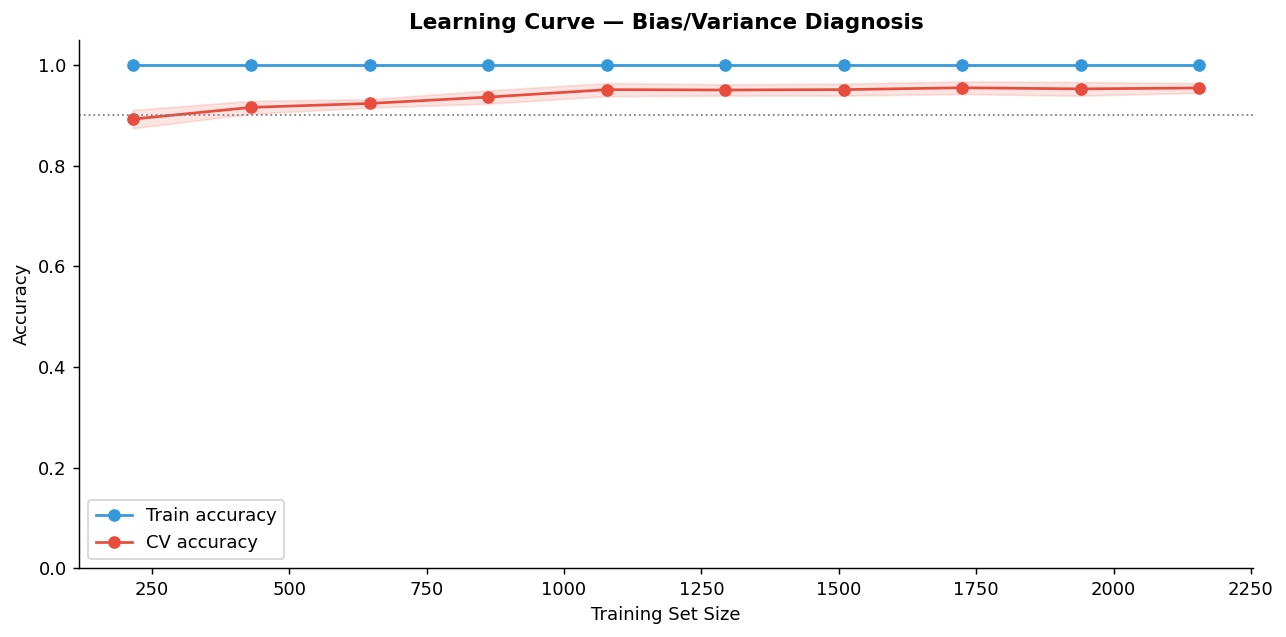

Final train acc: 1.0000
Final CV acc:    0.9544
Gap (overfit):   0.0456  ✅ Good


In [10]:
train_sizes, train_scores, val_scores = learning_curve(
    clf, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=42),
    train_sizes=np.linspace(0.1, 1.0, 10), scoring="accuracy", n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_sizes, train_mean, "o-", color="#3498db", label="Train accuracy")
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color="#3498db")
ax.plot(train_sizes, val_mean,   "o-", color="#e74c3c", label="CV accuracy")
ax.fill_between(train_sizes, val_mean   - val_std,   val_mean   + val_std,   alpha=0.15, color="#e74c3c")
ax.set_xlabel("Training Set Size")
ax.set_ylabel("Accuracy")
ax.set_title("Learning Curve — Bias/Variance Diagnosis", fontweight="bold")
ax.legend(); ax.set_ylim(0, 1.05)
ax.axhline(0.9, color="gray", linestyle=":", linewidth=1)
plt.tight_layout()
plt.savefig("notebooks/model_learning_curve.png", bbox_inches="tight")
plt.show()

gap = train_mean[-1] - val_mean[-1]
print(f"Final train acc: {train_mean[-1]:.4f}")
print(f"Final CV acc:    {val_mean[-1]:.4f}")
print(f"Gap (overfit):   {gap:.4f}  {'✅ Good' if gap < 0.05 else '⚠️ Moderate' if gap < 0.10 else '❌ High'}")


## 9. Population Stability Index (PSI) — Drift Monitoring

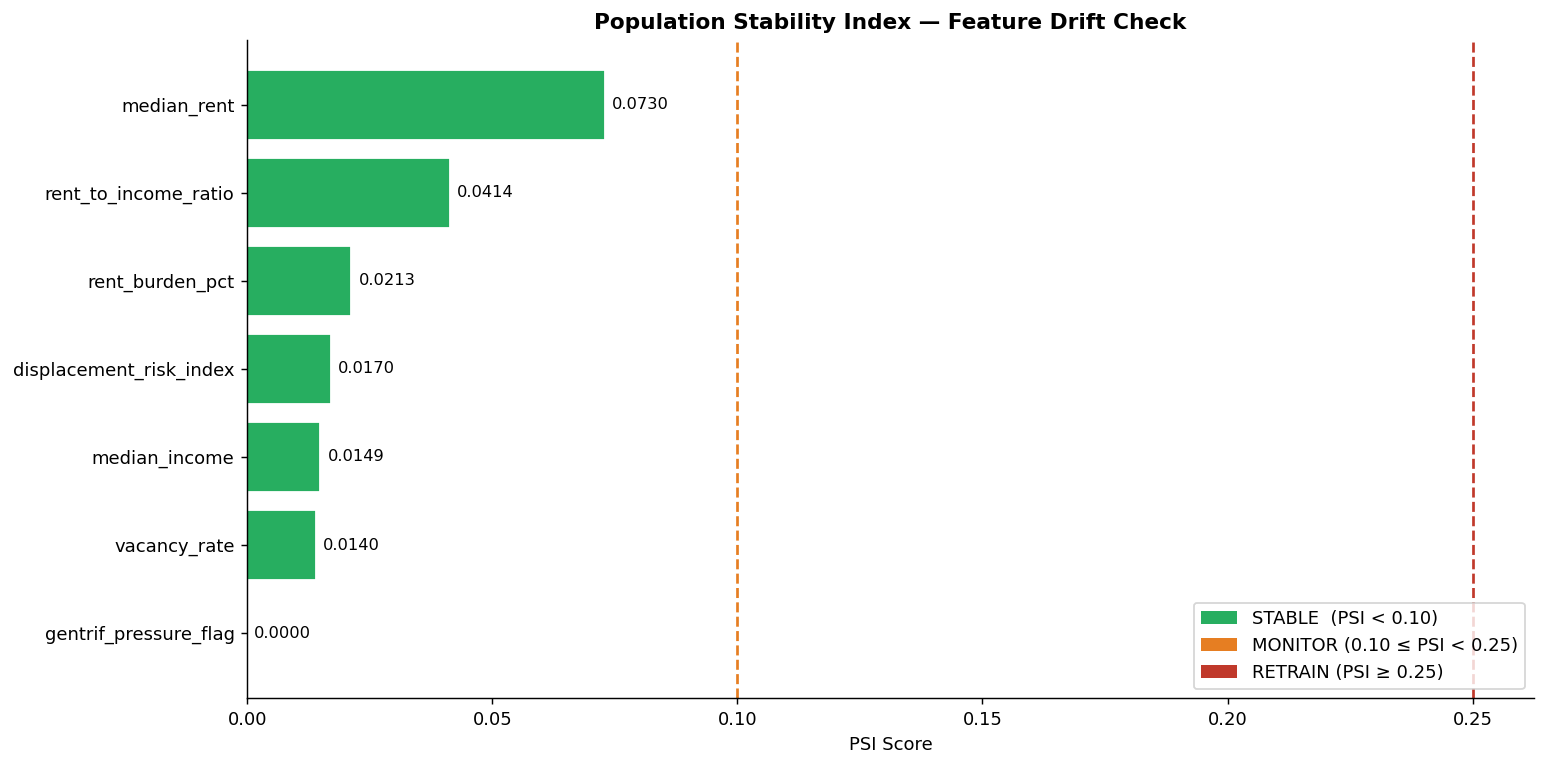

── Drift Summary ──────────────────────────────────────────────────────────
  STABLE  : ['rent_burden_pct', 'rent_to_income_ratio', 'vacancy_rate', 'median_income', 'median_rent', 'displacement_risk_index', 'gentrif_pressure_flag']

  Comparison method: year 2023 vs 2024


In [11]:
PSI_THRESHOLDS = {"STABLE": 0.10, "MONITOR": 0.25}

if has_drift and not drift_df.empty:
    fig, ax = plt.subplots(figsize=(12, 6))

    drift_sorted = drift_df.sort_values("psi_score", ascending=True)
    colors = [
        "#c0392b" if row["status"] == "RETRAIN"
        else "#e67e22" if row["status"] == "MONITOR"
        else "#27ae60"
        for _, row in drift_sorted.iterrows()
    ]
    bars = ax.barh(drift_sorted["feature"], drift_sorted["psi_score"],
                   color=colors, edgecolor="white")
    ax.bar_label(bars, labels=[f"{v:.4f}" for v in drift_sorted["psi_score"]],
                 padding=4, fontsize=9)
    ax.axvline(0.10, color="#e67e22", linestyle="--", linewidth=1.5, label="Monitor threshold (0.10)")
    ax.axvline(0.25, color="#c0392b", linestyle="--", linewidth=1.5, label="Retrain threshold (0.25)")
    ax.set_xlabel("PSI Score")
    ax.set_title("Population Stability Index — Feature Drift Check", fontweight="bold")
    ax.legend()

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="#27ae60", label="STABLE  (PSI < 0.10)"),
        Patch(facecolor="#e67e22", label="MONITOR (0.10 ≤ PSI < 0.25)"),
        Patch(facecolor="#c0392b", label="RETRAIN (PSI ≥ 0.25)"),
    ]
    ax.legend(handles=legend_elements, loc="lower right")
    plt.tight_layout()
    plt.savefig("notebooks/model_psi.png", bbox_inches="tight")
    plt.show()

    print("── Drift Summary ──────────────────────────────────────────────────────────")
    for status in ["RETRAIN","MONITOR","STABLE"]:
        subset = drift_df[drift_df["status"] == status]
        if len(subset) > 0:
            print(f"  {status:8s}: {list(subset['feature'].values)}")

    if "method" in drift_df.columns:
        print(f"\n  Comparison method: {drift_df['method'].iloc[0]}")
else:
    print("Drift log not available. Run src/monitor.py to generate PSI results.")
    print("\nPSI Interpretation Guide:")
    print("  PSI < 0.10 → STABLE    : Distribution is consistent, no action needed")
    print("  0.10–0.25  → MONITOR   : Notable shift, investigate root cause")
    print("  PSI > 0.25 → RETRAIN   : Significant distribution change, model retraining required")


## 10. Model Evaluation Summary

### GBM Classifier — Key Results
| Metric | Value | Interpretation |
|---|---|---|
| CV Accuracy (5-fold) | *run to populate* | Measures generalization across all data |
| Test Accuracy | *run to populate* | Held-out set performance |
| Critical Recall | *run to populate* | % of true Critical tracts correctly identified — most important metric |
| Low Recall | *run to populate* | % of stable tracts correctly identified |

### Design Validation
The GBM's feature importances should **broadly align** with the DRI manual weights. Significant divergence (>10pp difference for a DRI component) would indicate the index weights need recalibration. The notebook prints a divergence table in Section 7.

### PSI Monitoring
Features with PSI > 0.25 trigger an automatic retraining recommendation. Year-over-year drift in `rent_burden_pct` or `displacement_risk_index` would be the most consequential signals — these drive the DRI's predictive power.

### Next Steps
- If Critical Recall < 0.85, consider oversampling Critical tracts or adjusting DRI tier boundaries
- If any feature has PSI > 0.25, re-run `src/data_pipeline.py` + `src/features.py` + `src/model.py`
- Review the learning curve: a large train/CV gap > 0.10 signals overfitting → reduce `max_depth` or increase `min_samples_leaf`
